# NBA Full Game Viewer — Preview

Static screenshots of what the interactive viewer looks like.

To launch the real app:
```bash
python full_game_main.py --path data/0021500485.json
```

In [1]:
%matplotlib inline
import os, sys
from IPython.display import display

VIEWER_DIR = os.path.abspath('.')
PARENT_DIR = os.path.dirname(VIEWER_DIR)
sys.path.insert(0, PARENT_DIR)

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Circle, Rectangle

from GameTimeline import GameTimeline
from Constant import Constant
from Team import Team

In [2]:
tl = GameTimeline(os.path.join(VIEWER_DIR, 'data', '0021500485.json'))
tl.load()

Loading: e:\workspace_chuqi\phd_nba\visualization_tool\full_game_viewer\data\0021500485.json
Found 470 events. Deduplicating moments...
Loaded 79,302 unique frames (from 199,056 raw) across 4 quarters.
  Q1: frames 0 – 19,979  (19,980 frames)
  Q2: frames 19,980 – 40,405  (20,426 frames)
  Q3: frames 40,406 – 60,026  (19,621 frames)
  Q4: frames 60,027 – 79,301  (19,275 frames)


In [3]:
# ── constants ─────────────────────────────────────────────────────────
BG_DARK = '#0f0f1a'; BG_PANEL = '#16213e'; BG_SCORE = '#0d0d1a'
BTN_NORMAL = '#1e3a6e'; BTN_Q_ACTIVE = '#3d6abf'; BTN_S_ACTIVE = '#c8860a'
TEXT_DIM = '#aaaacc'; SHOT_URGENT = '#ff4444'
PR = Constant.PLAYER_CIRCLE_SIZE
BR = PR * 0.55; BMAX = PR * 1.10; TRAIL = 8
COURT = os.path.join(PARENT_DIR, 'courta.png')

def brighten(c):
    try:
        r,g,b = int(c[1:3],16),int(c[3:5],16),int(c[5:7],16)
        if (0.299*r+0.587*g+0.114*b)/255 >= 0.20: return c
        return f'#{int(r+.45*(255-r)):02x}{int(g+.45*(255-g)):02x}{int(b+.45*(255-b)):02x}'
    except: return c

TC = {tid: brighten(v[0]) for tid,v in Team.color_dict.items()}

def snapshot(tl, frame_idx, label=''):
    plt.style.use('dark_background')
    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor(BG_DARK)
    hid,vid,hn,vn = tl.get_team_info()
    hc = TC.get(hid,'#4fc3f7'); vc = TC.get(vid,'#ef9a9a')
    ha = Team.color_dict.get(hid,('#','HOM'))[1]
    va = Team.color_dict.get(vid,('#','VIS'))[1]
    hr,vr = tl.get_rosters(); pd = tl.get_player_dict()
    mo = tl.get_moment(frame_idx)
    oc = frozenset(p.id for p in mo.players)
    q  = mo.quarter
    try: gc=int(mo.game_clock); ts=f'Q{q}  {gc//60:02d}:{gc%60:02d}'
    except: ts=f'Q{q}  --:--'
    try:
        sc=mo.shot_clock; ss=f'{sc:04.1f}' if sc else ' N/A'
        sc_col = SHOT_URGENT if sc and sc<=5 else TEXT_DIM
    except: ss,sc_col=' N/A',TEXT_DIM

    # scoreboard
    sx=fig.add_axes([0,0.93,1,.07]); sx.axis('off'); sx.set_facecolor(BG_SCORE)
    sx.add_patch(Rectangle((0,0),.022,1,transform=sx.transAxes,facecolor=hc,zorder=1))
    sx.add_patch(Rectangle((.978,0),.022,1,transform=sx.transAxes,facecolor=vc,zorder=1))
    sx.text(.032,.5,f'{ha}   {hn}',transform=sx.transAxes,color=hc,ha='left',va='center',fontsize=11,fontweight='bold')
    sx.text(.968,.5,f'{vn}   {va}',transform=sx.transAxes,color=vc,ha='right',va='center',fontsize=11,fontweight='bold')
    sx.plot([.5,.5],[.1,.9],color='#334466',lw=.8,transform=sx.transAxes)
    sx.text(.5,.70,ts,transform=sx.transAxes,color='white',ha='center',va='center',fontsize=13,fontweight='bold')
    sx.text(.5,.22,f'Shot:  {ss}',transform=sx.transAxes,color=sc_col,ha='center',va='center',fontsize=9)

    # court
    cx=fig.add_axes([.02,.16,.68,.69]); cx.set_facecolor(BG_DARK); cx.axis('off')
    if os.path.exists(COURT):
        cx.imshow(plt.imread(COURT),zorder=0,
                  extent=[Constant.X_MIN,Constant.X_MAX-Constant.DIFF,Constant.Y_MAX,Constant.Y_MIN])
    cx.set_xlim(Constant.X_MIN,Constant.X_MAX); cx.set_ylim(Constant.Y_MIN,Constant.Y_MAX)
    # trail
    for back in range(TRAIL,0,-1):
        try:
            m=tl.get_moment(max(0,frame_idx-back))
            cx.add_patch(Circle((m.ball.x,m.ball.y),BR*(0.25+0.55*(TRAIL-back)/TRAIL),
                                 facecolor='#F47F20',alpha=(TRAIL-back+1)/TRAIL*0.45,zorder=1,linewidth=0))
        except: pass
    # players
    for p in mo.players:
        col=TC.get(p.team.id,p.color)
        cx.add_patch(Circle((p.x+.18,p.y-.18),PR*1.35,color='black',alpha=.25,zorder=2,linewidth=0))
        cx.add_patch(Circle((p.x,p.y),PR,facecolor=col,zorder=3,edgecolor='white',linewidth=1.8))
        if p.team.id==vid:
            cx.add_patch(Circle((p.x,p.y),PR*.48,facecolor='none',edgecolor='white',lw=1.2,alpha=.85,zorder=4))
        cx.text(p.x,p.y,pd.get(p.id,('?','?'))[1],color='white',ha='center',va='center',
                fontweight='bold',fontsize=9,zorder=6,
                path_effects=[pe.withStroke(linewidth=2.5,foreground='black'),pe.Normal()])
    # ball
    try:
        dr=min(BR+mo.ball.radius/Constant.NORMALIZATION_COEF,BMAX)
        cx.add_patch(Circle((mo.ball.x,mo.ball.y),dr,facecolor='#F47F20',zorder=4,edgecolor='#7B3A00',lw=1.5))
        cx.add_patch(Circle((mo.ball.x-dr*.27,mo.ball.y-dr*.27),dr*.28,color='white',alpha=.55,zorder=5,lw=0))
    except: pass

    # roster panel
    ix=fig.add_axes([.72,.16,.26,.69]); ix.axis('off')
    ix.add_patch(Rectangle((0,0),1,1,transform=ix.transAxes,facecolor=BG_PANEL,zorder=0))
    ix.text(.25,.97,hn,transform=ix.transAxes,color=hc,ha='center',va='top',fontsize=9,fontweight='bold')
    ix.text(.75,.97,vn,transform=ix.transAxes,color=vc,ha='center',va='top',fontsize=9,fontweight='bold')
    ix.plot([.5,.5],[.03,.95],color='#334466',lw=.6,transform=ix.transAxes,clip_on=False)
    nr=max(len(hr),len(vr),1); step=(0.88-0.06)/nr; fs=max(6.5,min(8.,step*22)); y=0.91
    for i in range(nr):
        for roster,col,xpos in [(hr,hc,.02),(vr,vc,.52)]:
            if i<len(roster):
                nm,jn,pid=roster[i]; on=pid in oc
                ix.text(xpos,y,f'{"●" if on else " "}  #{jn:<3} {nm}',transform=ix.transAxes,
                        ha='left',va='top',fontsize=fs,
                        color='white' if on else '#445566',fontweight='bold' if on else 'normal')
        y-=step

    # timeline
    tx=fig.add_axes([.02,.07,.68,.04]); tx.set_facecolor('#1a2744')
    tx.set_xlim(0,tl.total_frames); tx.set_ylim(0,1); tx.axis('off')
    for qn in tl.quarters:
        qi=tl.quarter_starts[qn]; tx.axvline(x=qi,color='white',alpha=.35,lw=1.5)
        tx.text(qi+tl.total_frames*.003,1.18,f'Q{qn}',transform=tx.get_xaxis_transform(),
                color='white',fontsize=7.5,ha='left',va='bottom',clip_on=False)
    tx.axvline(x=frame_idx,color='#4caf50',lw=2.5,zorder=5)
    tx.fill_betweenx([0,1],0,frame_idx,color='#4caf50',alpha=.18)
    tx.text(.5,-.65,ts,transform=tx.transAxes,color=TEXT_DIM,fontsize=8,ha='center',va='top',clip_on=False)

    # buttons
    BY=.87; BH=.05
    for i,qn in enumerate(tl.quarters):
        ax=fig.add_axes([.02+i*.075,BY,.07,BH]); ax.set_facecolor(BTN_Q_ACTIVE if qn==q else BTN_NORMAL); ax.axis('off')
        ax.text(.5,.5,f'Q{qn}',color='white',ha='center',va='center',fontsize=10,fontweight='bold',transform=ax.transAxes)
    ap=fig.add_axes([.34,BY,.14,BH]); ap.set_facecolor('#1b5e20'); ap.axis('off')
    ap.text(.5,.5,'▶  Play',color='white',ha='center',va='center',fontsize=11,transform=ap.transAxes)
    for i,lb in enumerate(['0.5×','1×','2×','4×']):
        ax=fig.add_axes([.510+i*.044,BY,.040,BH]); ax.set_facecolor(BTN_S_ACTIVE if lb=='1×' else BTN_NORMAL); ax.axis('off')
        ax.text(.5,.5,lb,color='white',ha='center',va='center',fontsize=9,transform=ax.transAxes)
    ah=fig.add_axes([.692,BY,.028,BH]); ah.set_facecolor(BTN_NORMAL); ah.axis('off')
    ah.text(.5,.5,'?',color='white',ha='center',va='center',fontsize=10,transform=ah.transAxes)

    if label:
        fig.text(.5,.005,label,color=TEXT_DIM,ha='center',fontsize=8)
    return fig

### Q1 — Tip-off

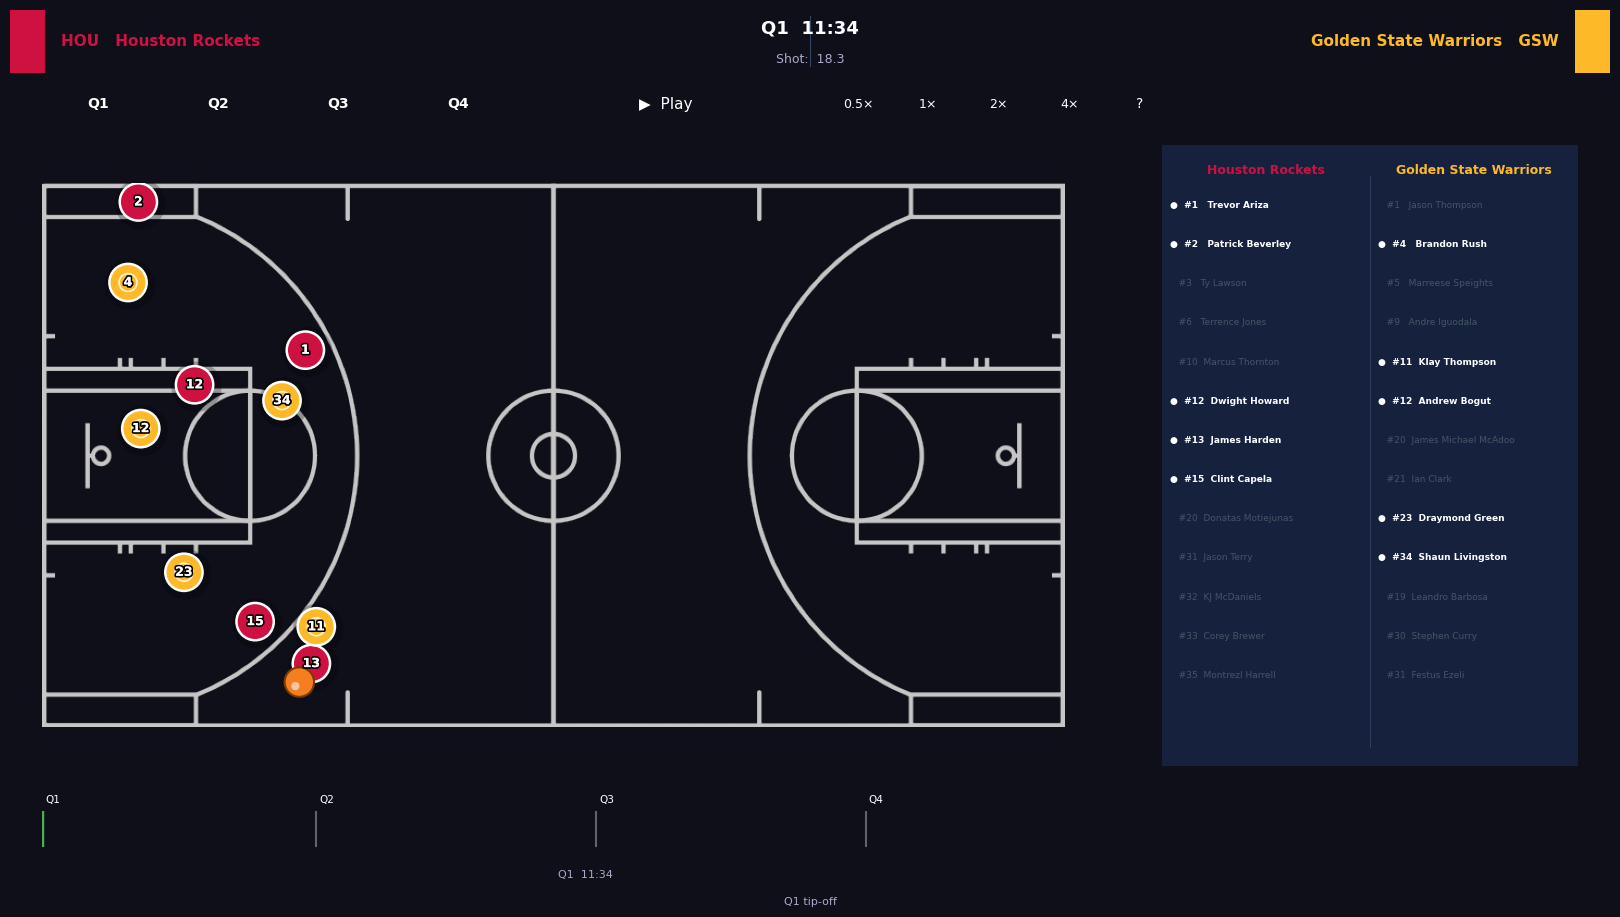

In [4]:
fig = snapshot(tl, tl.quarter_starts[1], 'Q1 tip-off')
display(fig); plt.close(fig)

### Mid-game

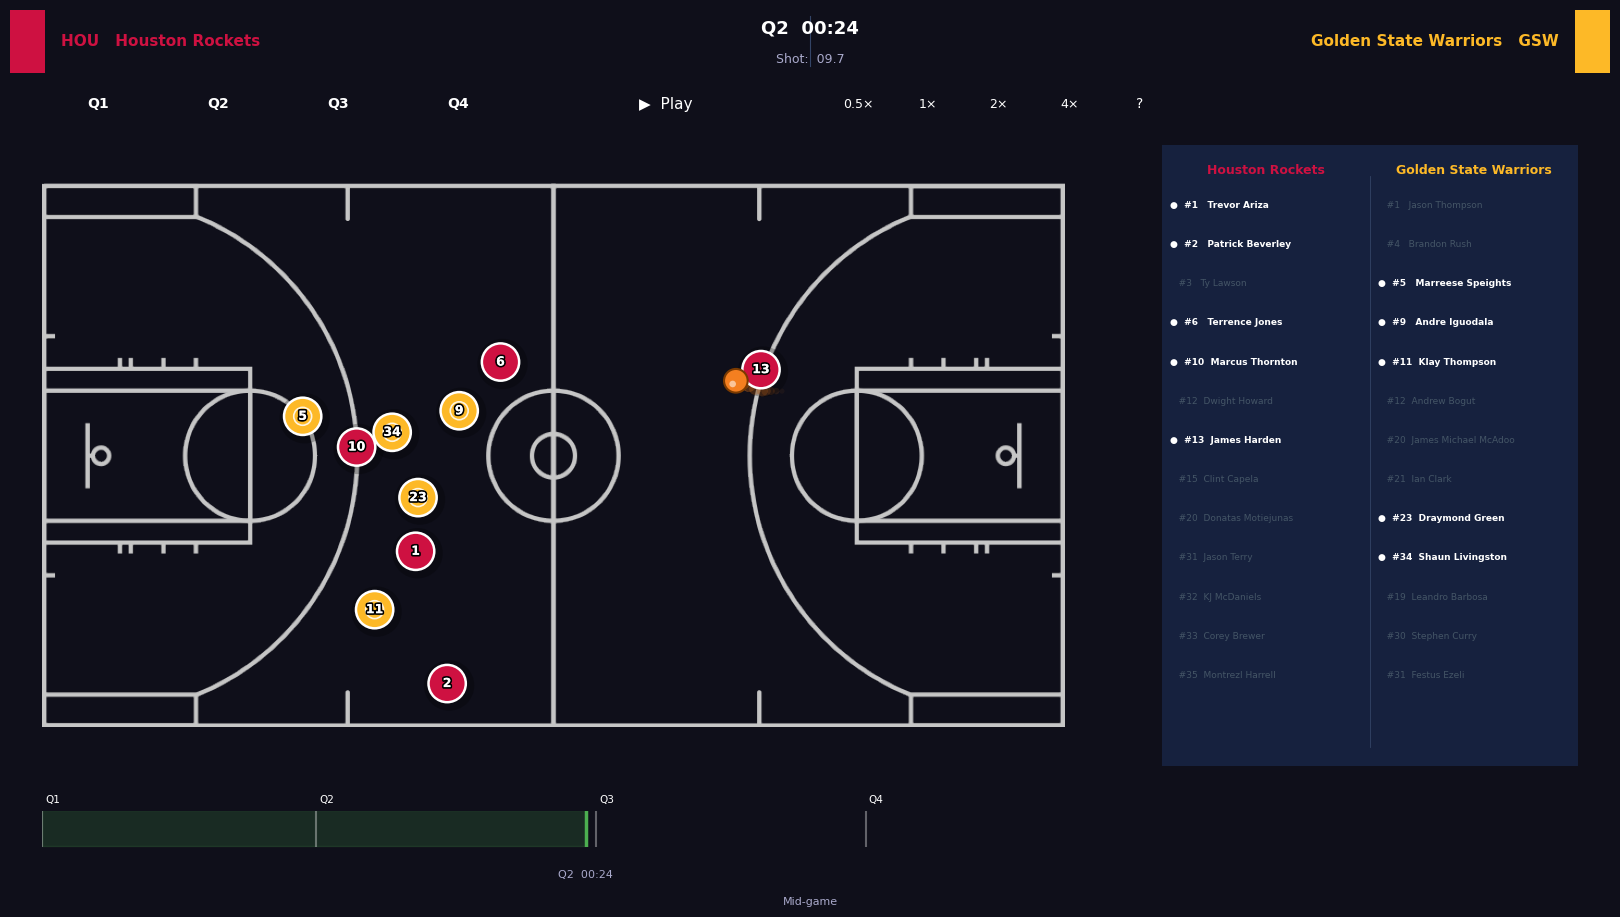

In [5]:
fig = snapshot(tl, tl.total_frames // 2, 'Mid-game')
display(fig); plt.close(fig)

### Q4 — Final stretch

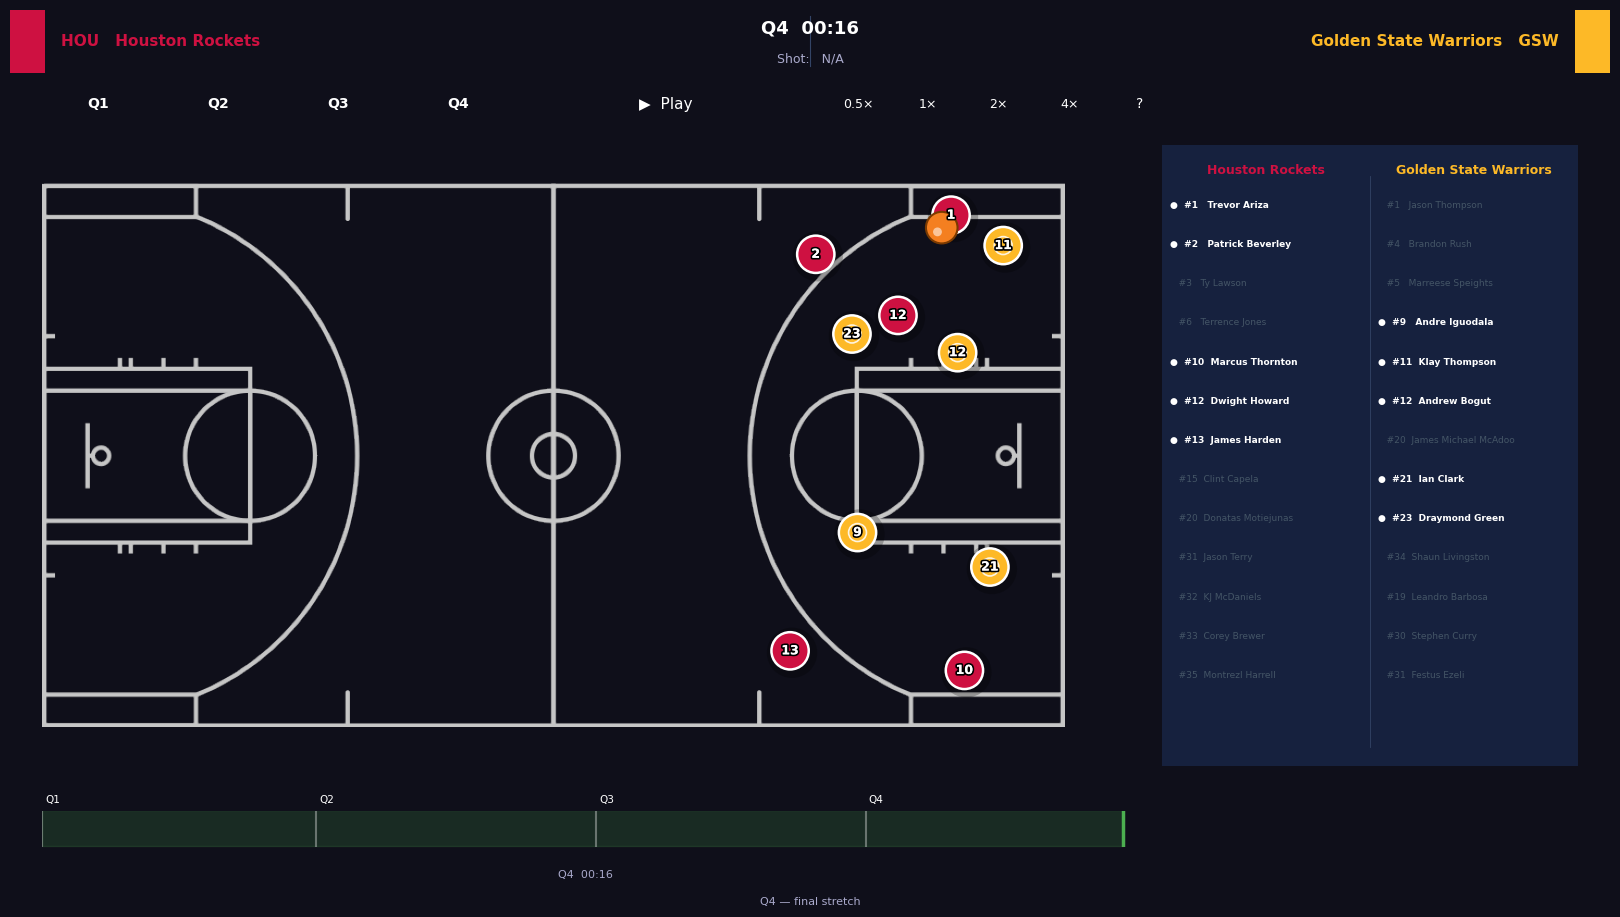

In [6]:
fig = snapshot(tl, tl.total_frames - 500, 'Q4 — final stretch')
display(fig); plt.close(fig)